# Notebook de suivi — prototypage RL sur `toy_lob`

Ce notebook sert à **documenter la progression du projet** et à **tester les briques principales** déjà implémentées.

Ordre retenu :
1. visualiser le marché simplifié `toy_lob` ;
2. valider la collecte d'une trajectoire ;
3. tester un épisode complet Actor–Critic ;
4. observer l'entraînement Actor–Critic sur plusieurs épisodes ;
5. observer l'entraînement PPO sur plusieurs épisodes ;
6. construire et analyser les nouvelles features de marché.

L'objectif de cette phase n'est **pas** encore d'obtenir une stratégie réaliste, mais de valider l'ossature RL sur un environnement volontairement simplifié.

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:", project_root)

Project root: /Users/franciscegoat/mm-rl


In [2]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet, CriticNet
from src.utils.device import get_device
from src.utils.visualisation import plot_lob, plot_episode_dynamics, run_training_experiment
from src.features.market_features import build_market_features

import scripts.train_loop as tr_lp

device = get_device()
print("Device:", device)

[Device] Using mps
[Device] Using mps
Device: mps


## Étape 1 — Visualisation du `toy_lob`

On commence par regarder **la structure du marché simulé** : mid-price, bid, ask, spread et signal d'imbalance.

### Note carnet de suivi
Le marché simplifié est utilisé ici comme **support de prototypage**. L'enjeu n'est pas encore la fidélité microstructurelle, mais la mise en place d'un pipeline RL complet.

In [3]:
market = pd.read_csv("data/raw/toy_lob.csv")
market.head()

,mid,bid,ask,bid_vol,ask_vol
0,100.000000,99.995000,100.005000,8,15
1,100.062333,100.057333,100.067333,4,5
2,100.044971,100.039971,100.049971,11,9
3,100.126287,100.121287,100.131287,8,11
4,100.317655,100.312655,100.322655,8,16


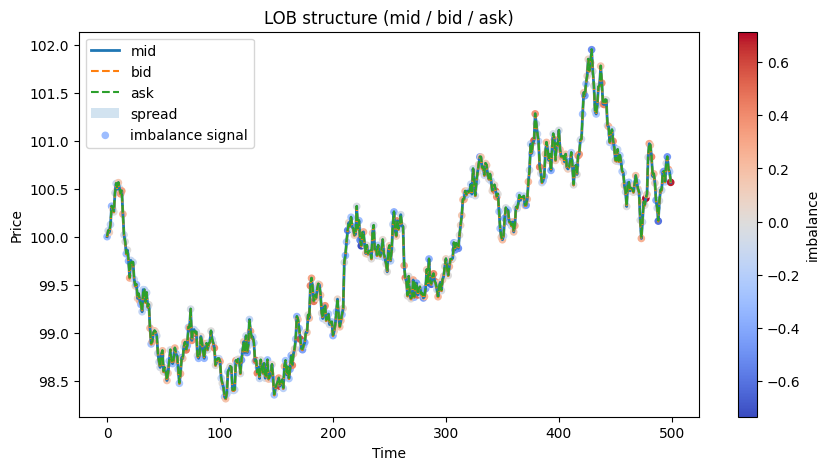

In [4]:
plot_lob(market, n_points=500)

## Étape 2 — Validation de `collect_trajectory`

On vérifie qu'une trajectoire complète peut être collectée sous la politique courante, avec des tenseurs cohérents pour :
- `states`
- `actions`
- `rewards`
- `old_log_probs`

### Note carnet de suivi
La collecte de trajectoire constitue le point de jonction entre :
- la politique (`ActorNet`) ;
- l'environnement (`MMSimulator`) ;
- les boucles d'entraînement.

In [5]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim= env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

In [6]:
trajectory = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=200
)

states = trajectory["states"]
actions = trajectory["actions"]
rewards = trajectory["rewards"]
old_log_probs = trajectory["old_log_probs"]

print("Shapes :")
print("states       :", states.shape)
print("actions      :", actions.shape)
print("rewards      :", rewards.shape)
print("log_probs    :", old_log_probs.shape)

print("\nTypes :")
print("states       :", states.dtype, states.device)
print("actions      :", actions.dtype, actions.device)
print("rewards      :", rewards.dtype, rewards.device)
print("log_probs    :", old_log_probs.dtype, old_log_probs.device)

print("\nSanity checks :")
print("nb steps     :", len(rewards))
print("reward mean  :", rewards.mean().item())
print("reward std   :", rewards.std().item())
print("action range :", actions.min().item(), ",", actions.max().item())

assert not torch.isnan(states).any()
assert not torch.isnan(actions).any()
assert not torch.isnan(rewards).any()
assert not torch.isnan(old_log_probs).any()
print("\nTests simples passés.")

Shapes :
states       : torch.Size([200, 4])
actions      : torch.Size([200, 1])
rewards      : torch.Size([200])
log_probs    : torch.Size([200, 1])

Types :
states       : torch.float32 mps:0
actions      : torch.float32 mps:0
rewards      : torch.float32 mps:0
log_probs    : torch.float32 mps:0

Sanity checks :
nb steps     : 200
reward mean  : -0.021412208676338196
reward std   : 0.3735356032848358
action range : 0.0001716569095151499 , 0.04920674487948418

Tests simples passés.


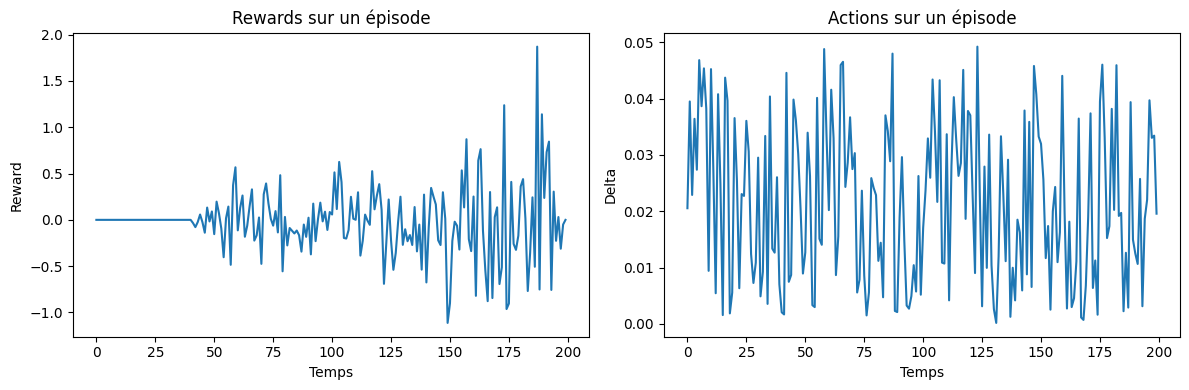

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards.cpu().numpy())
plt.title("Rewards sur un épisode")
plt.xlabel("Temps")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(actions.cpu().numpy())
plt.title("Actions sur un épisode")
plt.xlabel("Temps")
plt.ylabel("Delta")

plt.tight_layout()
plt.show()

## Étape 3 — Test d'un épisode complet Actor–Critic

On valide ici le pipeline local :
1. collecte ;
2. calcul des returns ;
3. entraînement du critic ;
4. calcul des avantages ;
5. entraînement de l'acteur.

### Note carnet de suivi
Cette étape correspond à la fermeture d'une première boucle **Actor–Critic simple**, avant l'introduction de PPO.

Temps total : 20.862070083618164

--- Sanity checks (PPO) ---
Nb épisodes : 50
Critic loss (last) : 0.5909105539321899
Actor loss  (last) : -0.0021488917991518974
Return moyen : -0.710741006731987
Return min / max : -11.091203689575195 9.451289176940918


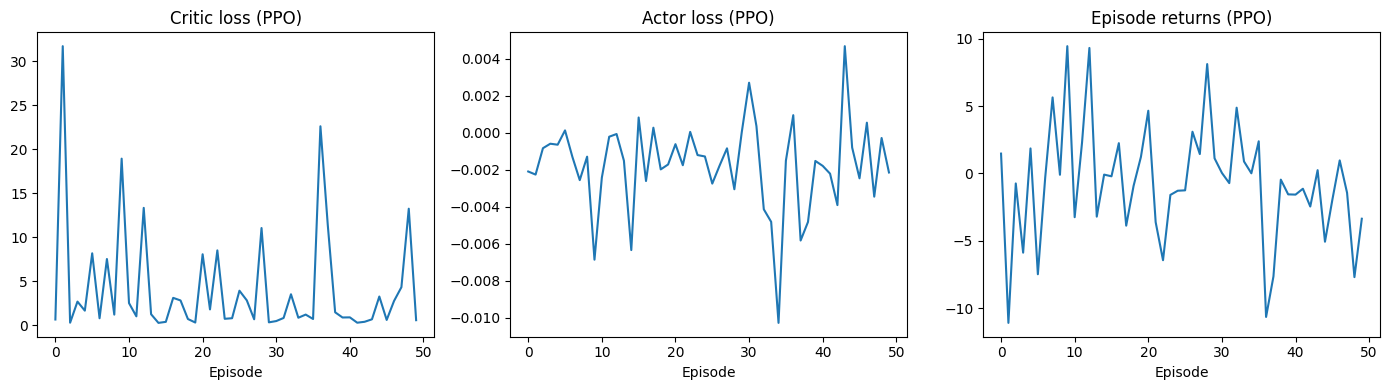

In [8]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim= env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False,
    label="PPO"
)

## Étape 4 — Entraînement sur plusieurs épisodes : Actor–Critic classique

On observe ici le comportement de la version **sans clipping PPO**.

### Note carnet de suivi
Cette étape a permis de mettre en évidence une forte instabilité de l'Actor–Critic classique dans cet environnement simplifié.

Temps total : 21.97489881515503

--- Sanity checks (PPO) ---
Nb épisodes : 50
Critic loss (last) : 0.02688787691295147
Actor loss  (last) : 0.06583508849143982
Return moyen : tensor(-0.2179)
Return min / max : tensor(-8.5975) tensor(10.6029)


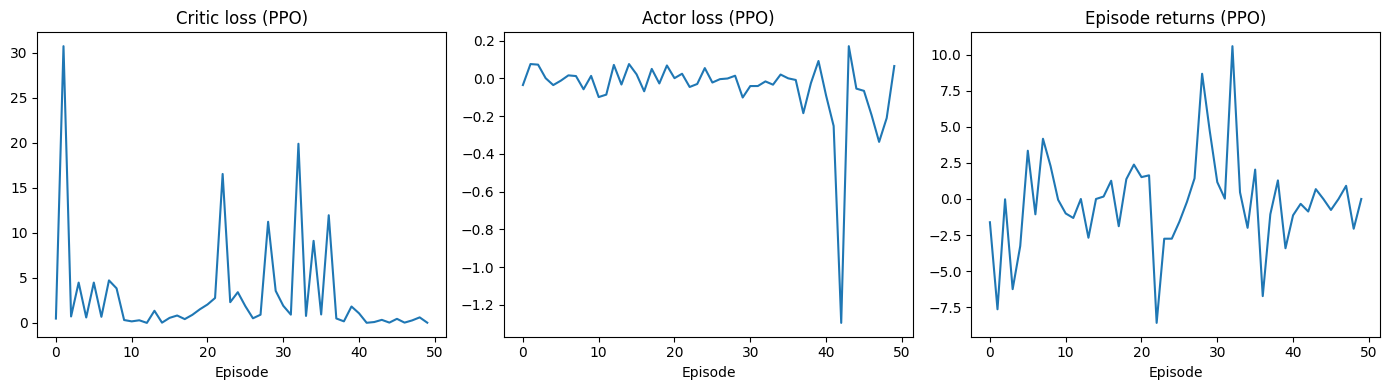

In [9]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_actor_critic,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False,
    label="PPO"
)


## Étape 5 — Entraînement sur plusieurs épisodes : PPO

On remplace ici la perte actor simple par la perte PPO clipée.

### Note carnet de suivi
Le passage à PPO stabilise nettement l'apprentissage de l'acteur, même si le signal de reward reste bruité dans le cadre du `toy_lob`.

Temps total : 20.05910015106201

--- Sanity checks (PPO) ---
Nb épisodes : 50
Critic loss (last) : 3.6997923851013184
Actor loss  (last) : 0.0003088402736466378
Return moyen : 0.2839397132396698
Return min / max : -9.204960823059082 10.10634994506836


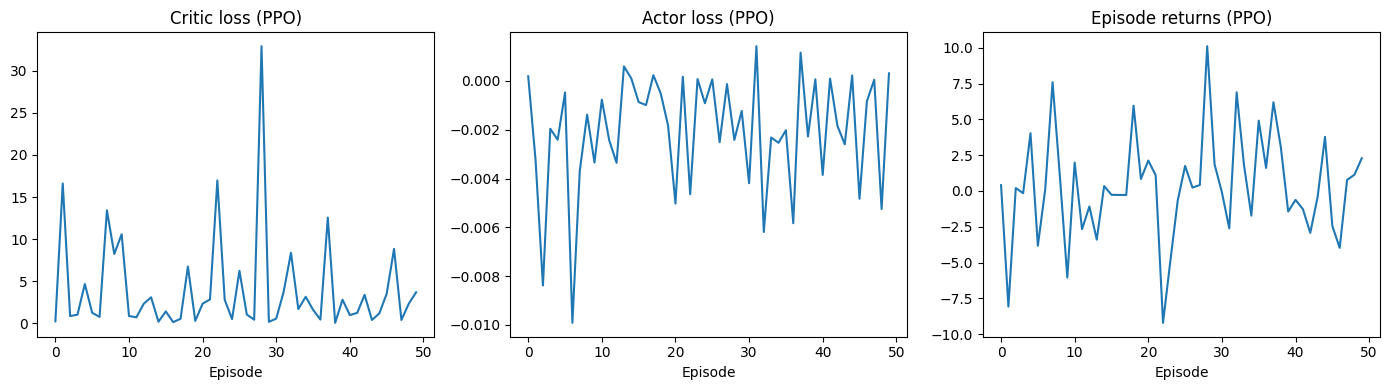

In [10]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False,
    label="PPO"
)



## Étape 6 — Construction des nouvelles features de marché

On enrichit ici les données brutes avec :
- `spread`
- `imbalance`
- `microprice`
- `return_1`
- `ma_10`
- `ma_20`
- `rsi_14`

### Note carnet de suivi
Ces features rapprochent l'état de l'esprit de l'article, même si le marché jouet reste trop pauvre pour qu'elles deviennent réellement prédictives.

In [11]:
df_feat = build_market_features(market)
df_feat.head()

,mid,bid,ask,bid_vol,ask_vol,spread,imbalance,microprice,return_1,ma_10,ma_15,ma_20,ma_30,rsi_14
0,100.000000,99.995000,100.005000,8.0,15.0,0.01,-0.304348,99.998478,0.000000,100.000000,100.000000,100.000000,100.000000,0.000000
1,100.062333,100.057333,100.067333,4.0,5.0,0.01,-0.111111,100.061778,0.062333,100.031167,100.031167,100.031167,100.031167,100.000000
2,100.044971,100.039971,100.049971,11.0,9.0,0.01,0.100000,100.045471,-0.017362,100.035768,100.035768,100.035768,100.035768,78.214740
3,100.126287,100.121287,100.131287,8.0,11.0,0.01,-0.157895,100.125498,0.081316,100.058398,100.058398,100.058398,100.058398,89.217015
4,100.317655,100.312655,100.322655,8.0,16.0,0.01,-0.333333,100.315989,0.191368,100.110249,100.110249,100.110249,100.110249,95.072984


In [12]:
print(df_feat[["mid", "spread", "imbalance", "microprice", "return_1", "ma_10", "ma_20", "rsi_14"]].describe())

                mid        spread     imbalance    microprice      return_1  \
count  10000.000000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean     102.069233  1.000000e-02     -0.002606    102.069220     -0.000349   
std        6.299184  1.224576e-14      0.229400      6.299214      0.128625   
min       91.508282  1.000000e-02     -1.000000     91.509711     -0.478503   
25%       96.894763  1.000000e-02     -0.157895     96.894439     -0.086273   
50%      100.445531  1.000000e-02      0.000000    100.444557     -0.000345   
75%      108.767010  1.000000e-02      0.153846    108.766484      0.084872   
max      114.692521  1.000000e-02      0.857143    114.691921      0.549181   

              ma_10         ma_20        rsi_14  
count  10000.000000  10000.000000  10000.000000  
mean     102.070812    102.072604     49.910619  
std        6.296168      6.293118     15.916419  
min       91.687731     91.834155      0.000000  
25%       96.917547     96.941590     

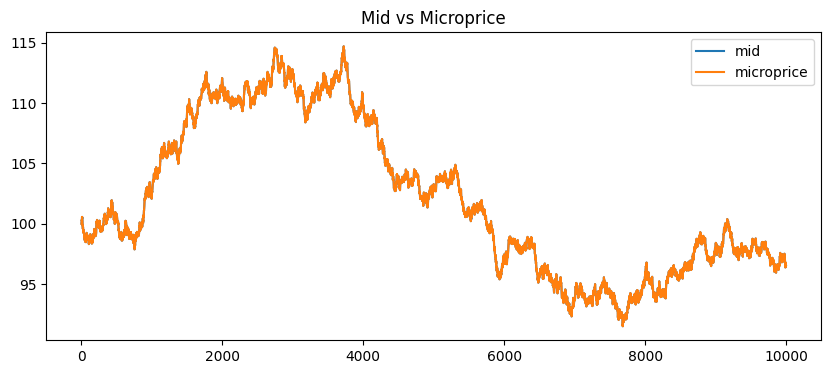

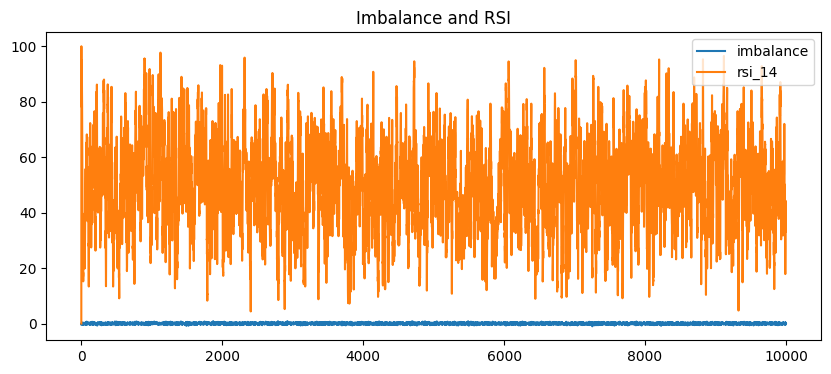

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(df_feat["mid"], label="mid")
plt.plot(df_feat["microprice"], label="microprice")
plt.legend()
plt.title("Mid vs Microprice")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_feat["imbalance"], label="imbalance")
plt.plot(df_feat["rsi_14"], label="rsi_14")
plt.legend()
plt.title("Imbalance and RSI")
plt.show()

## Lancement de l'algo PPO en mode engeneered pour comparer 

In [14]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42, state_mode="engineered")

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

history_ppo = tr_lp.train_ppo(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False
)

elapsed = time.time() - t0
print("Temps total :", elapsed)

critic_loss_ppo = history_ppo["critic_loss"]
actor_loss_ppo = history_ppo["actor_loss"]
returns_ppo = history_ppo["episode_return"]

print("\n--- Sanity checks ---")
print("Nb épisodes :", len(returns_ppo))
print("Critic loss (last) :", critic_loss_ppo[-1])
print("Actor loss  (last) :", actor_loss_ppo[-1])
print("Return moyen :", sum(returns_ppo)/len(returns_ppo))
print("Return min / max :", min(returns_ppo), max(returns_ppo))

Temps total : 19.78584384918213

--- Sanity checks ---
Nb épisodes : 50
Critic loss (last) : 12.046187400817871
Actor loss  (last) : -0.00045953987864777446
Return moyen : 0.3019495075941086
Return min / max : -17.52914810180664 10.405710220336914


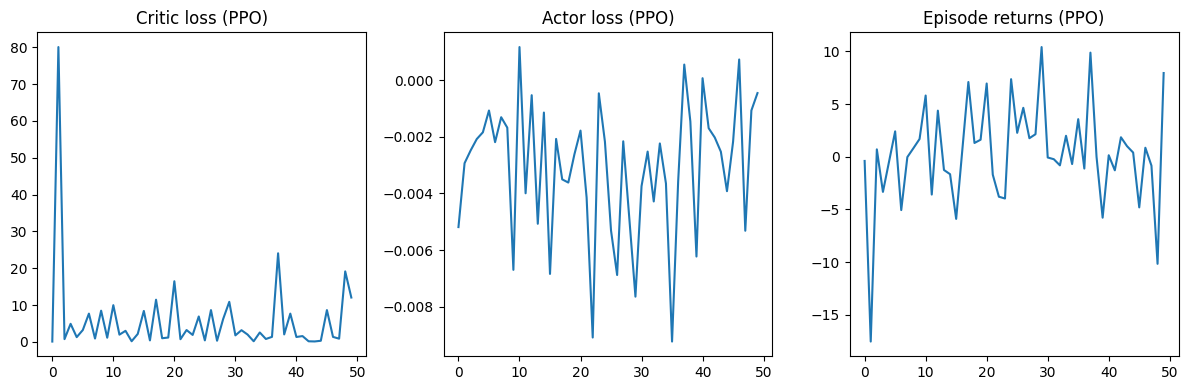

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(critic_loss_ppo)
plt.title("Critic loss (PPO)")

plt.subplot(1, 3, 2)
plt.plot(actor_loss_ppo)
plt.title("Actor loss (PPO)")

plt.subplot(1, 3, 3)
plt.plot(returns_ppo)
plt.title("Episode returns (PPO)")

plt.tight_layout()
plt.show()

Pour le moment la différence n'est pas flagrante, ce qui peut venir comme on l'a vu précédemment du manque d'informations observables dans les nouvelles features. 

## Conclusion provisoire

À ce stade :

- le **pipeline RL** est en place ;
- la **collecte de trajectoires** fonctionne ;
- l'**Actor–Critic classique** est instable dans ce cadre ;
- **PPO** stabilise nettement mieux les mises à jour ;
- les **features de marché enrichies** sont construites, mais encore peu informatives dans le `toy_lob`.

La suite logique du projet n'est plus l'algorithme RL lui-même, mais l'**enrichissement du simulateur** :
1. rendre l'état plus informatif ;
2. coupler plus fortement carnet et dynamique de prix ;
3. enrichir l'espace d'action.

## Implémentation d'un générateur de Data plus complet 
Implémentation du Dataset complété par : 
\begin{itemize}
\item
\end{itemize}

In [16]:
from scripts.generate_data import generate_toy_lob_nonstationary, generate_toy_lob_simple
df_simple = generate_toy_lob_simple()
df_non_sationnary = generate_toy_lob_nonstationary()


[generate_toy_lob_simple] saved to data/raw/toy_lob_simple_seed42.csv
[generate_toy_lob_simple] saved to data/raw/toy_lob_non_stationnary_seed42.csv


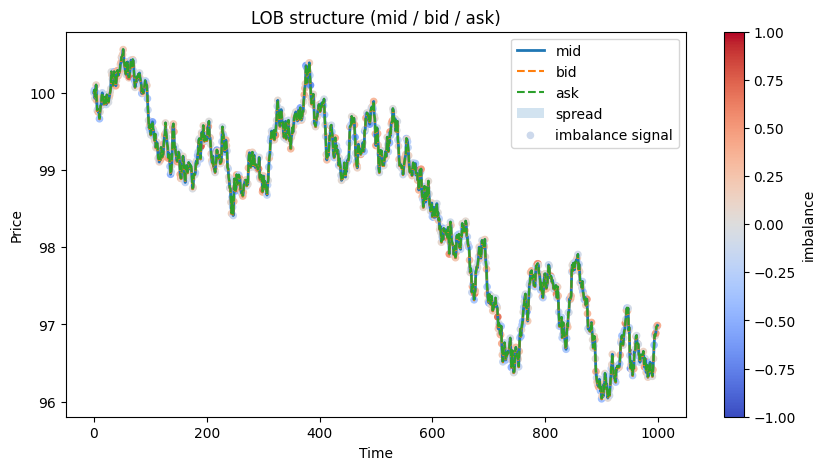

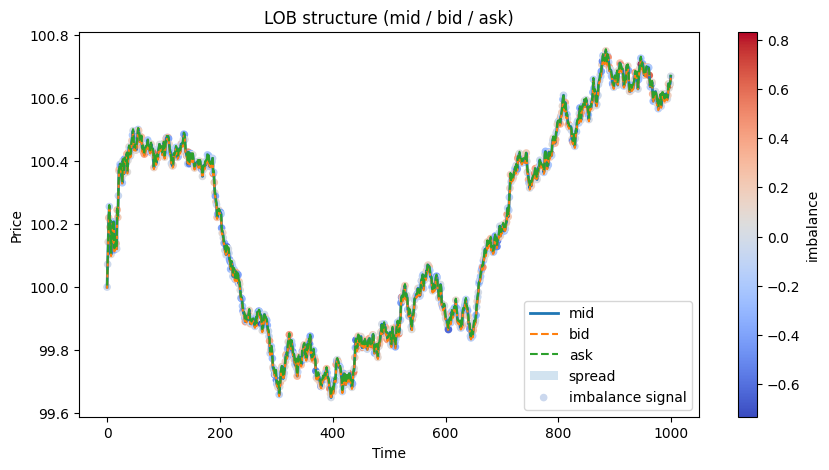

In [17]:
plot_lob(df_simple, 1000)
plot_lob(df_non_sationnary, 1000)

### Entrainement sur le nouvel environnement


Temps total : 21.137820959091187

--- Sanity checks (PPO) ---
Nb épisodes : 50
Critic loss (last) : 0.07003168016672134
Actor loss  (last) : -0.002332930453121662
Return moyen : -0.044710943028330806
Return min / max : -3.476930618286133 2.8933441638946533


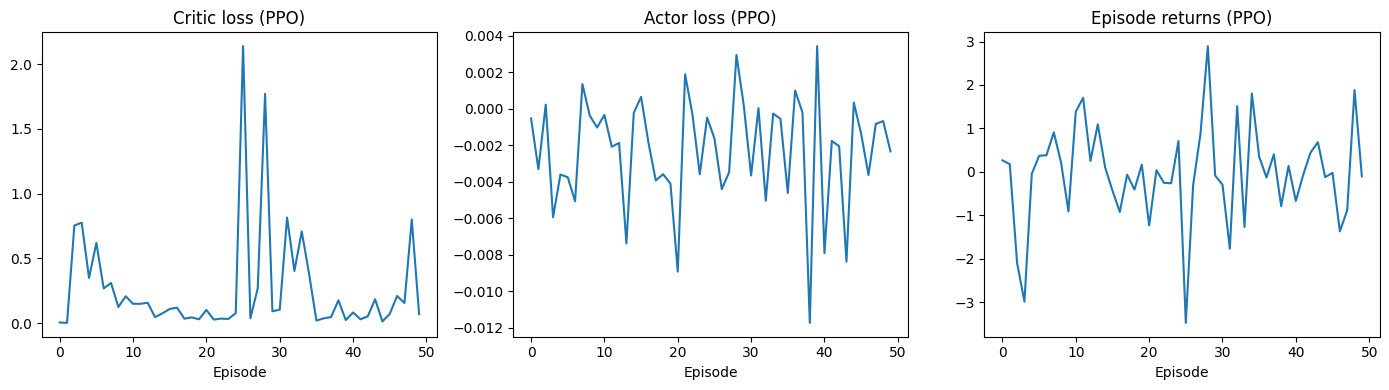

In [18]:
env = MMSimulator(csv_path="data/raw/toy_lob_non_stationnary_seed42.csv", seed=42, state_mode="simple")

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False,
    label="PPO"
)



Temps total : 20.97526502609253

--- Sanity checks (PPO) ---
Nb épisodes : 50
Critic loss (last) : 0.021951962262392044
Actor loss  (last) : -0.0009436190011911094
Return moyen : 0.11037775434553623
Return min / max : -3.654165267944336 3.0390381813049316


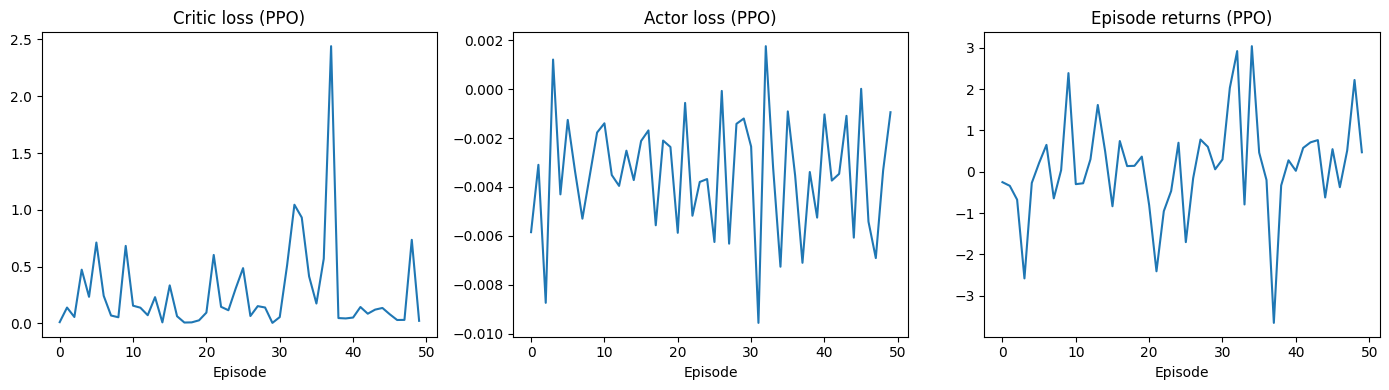

In [19]:
env = MMSimulator(csv_path="data/raw/toy_lob_non_stationnary_seed42.csv", seed=42, state_mode="engineered")

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False,
    label="PPO"
)




Nous allons montrer la dynamique de deux épisodes de trading selon l'impact que l'on a sur le marché. 

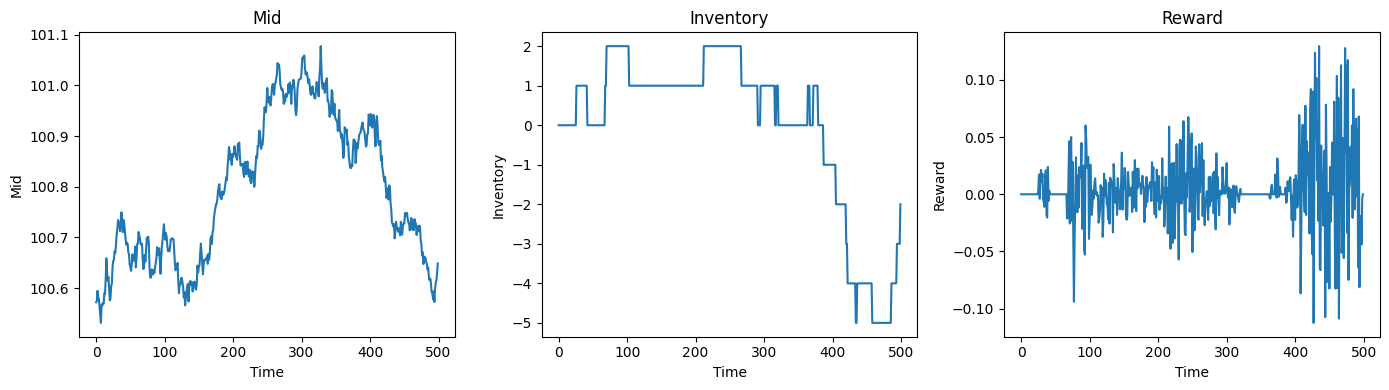

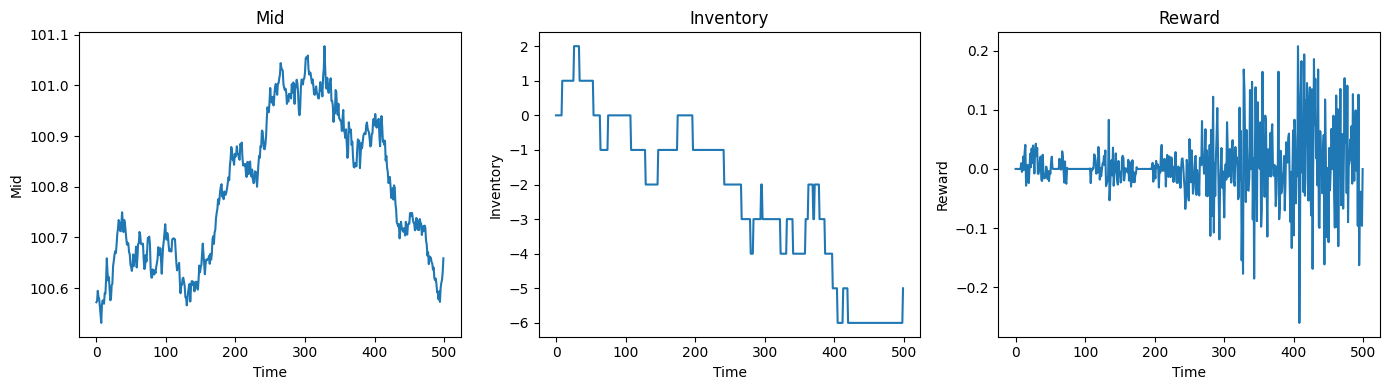

In [20]:
modes = ["baseline", "impact"]
for mode in modes: 
    env = MMSimulator(csv_path="data/raw/toy_lob_non_stationnary_seed42.csv", seed=42, state_mode="engineered", dynamic_mode= mode)
    plot_episode_dynamics(env)

In [21]:
import torch
import time
import matplotlib.pyplot as plt

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

env = MMSimulator(
    csv_path="data/raw/toy_lob.csv",
    seed=42,
    eta_inv=1e-2,
    state_mode="engineered",      # ou "simple"
    dynamic_mode="impact"        # ou "baseline"
)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,                 # <- action 1D
    delta_min=0.0,
    delta_max=0.05,
    q_min=1.0,
    q_max=5.0
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

print("state_dim :", env.state_dim)
print("device    :", device)


state_dim : 9
device    : mps


Temps total : 109.63147068023682

--- Sanity checks (PPO) ---
Nb épisodes : 100
Critic loss (last) : 34.9829216003418
Actor loss  (last) : -0.00738507742062211
Return moyen : -67.84235953092575
Return min / max : -413.20404052734375 -0.46212029457092285


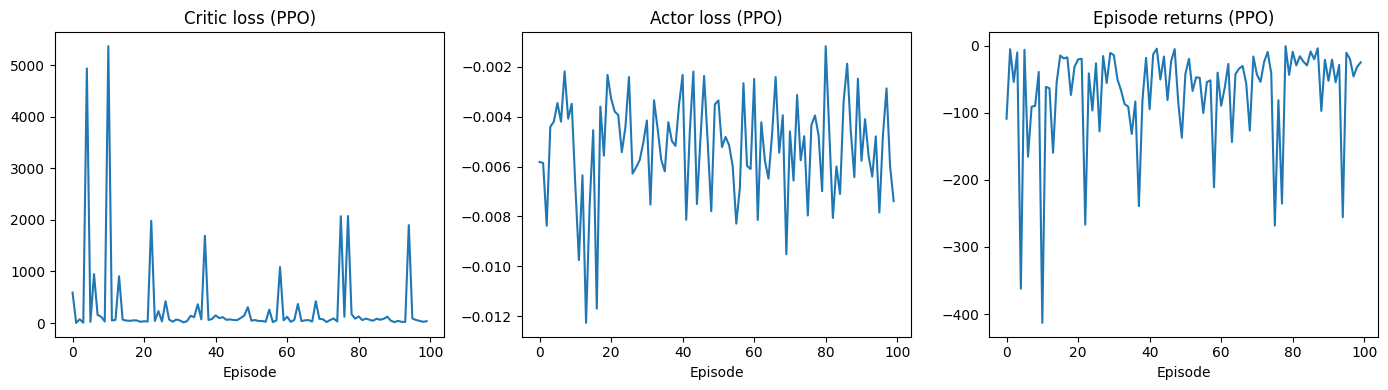

In [22]:
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=100,
    n_epochs_actor=15,
    n_epochs_critic=30,
    random_reset=True,
    max_steps=500,
    verbose=False,
    label="PPO"
)

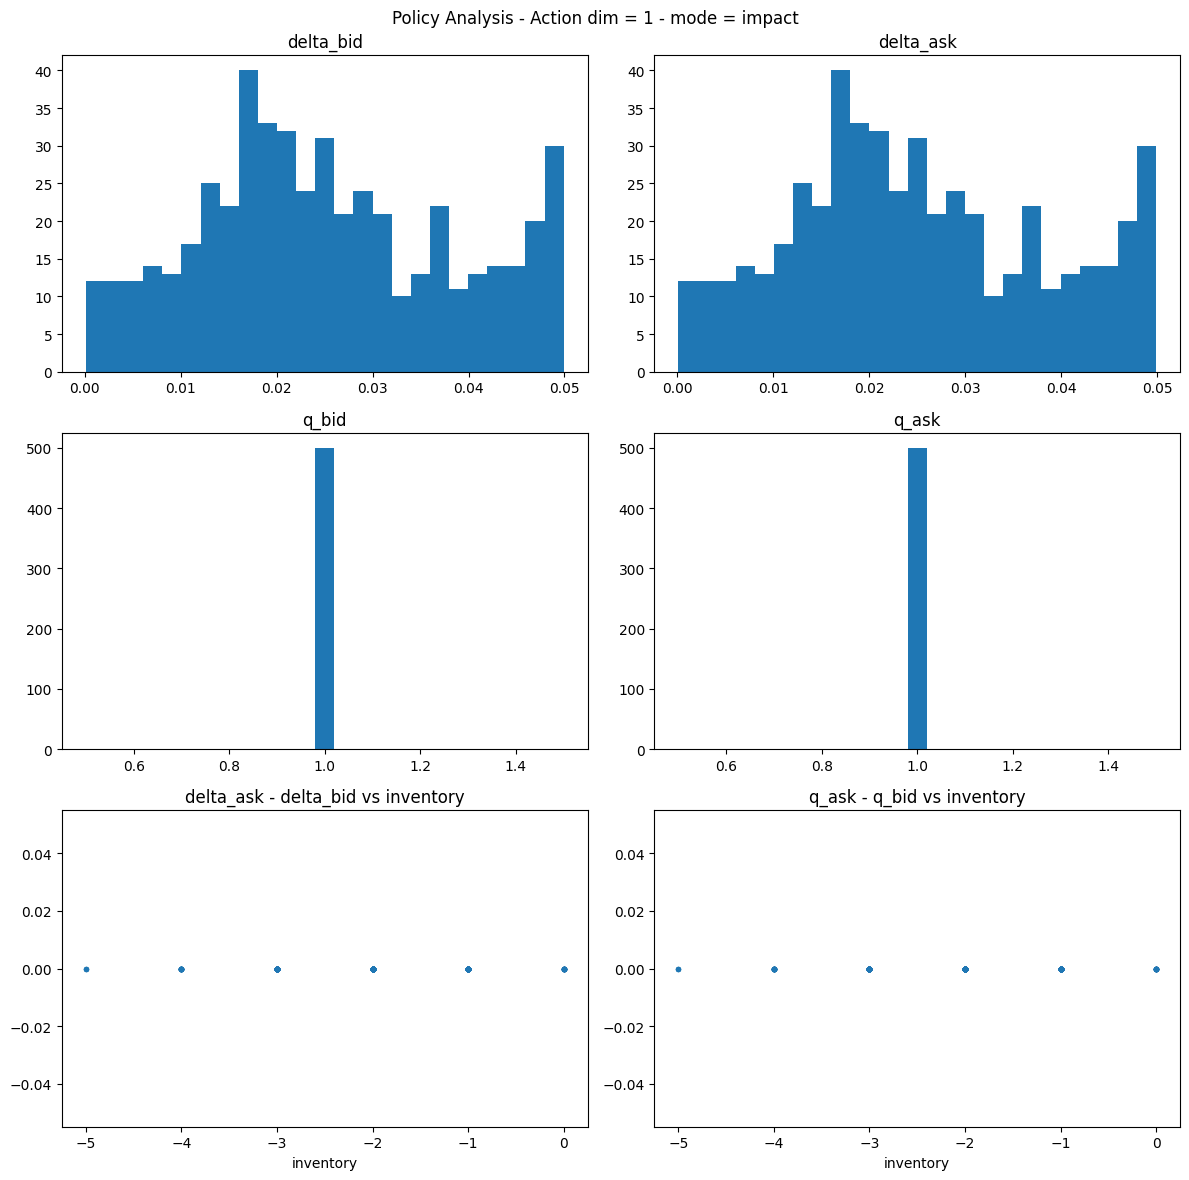

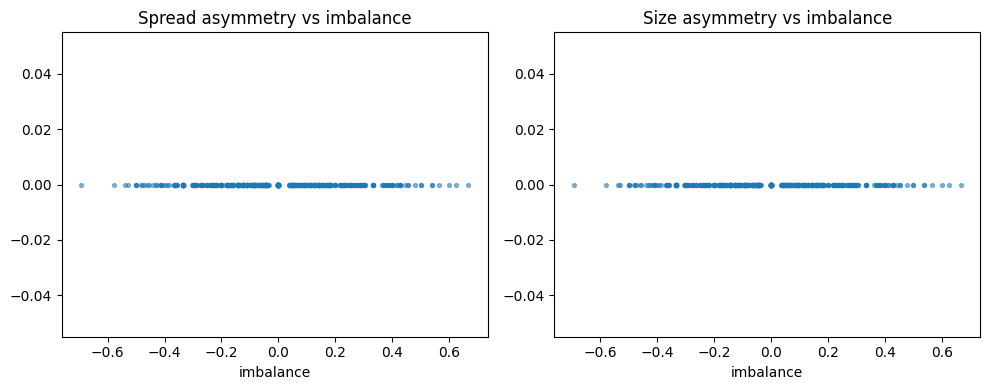

In [23]:
from src.utils.visualisation import analyze_policy_actions

traj = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=500
)

analyze_policy_actions(traj,env,actor=actor,  inventory_index=-1, imbalance_index=2)

In [24]:
import torch
import time
import matplotlib.pyplot as plt

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

env = MMSimulator(
    csv_path="data/raw/toy_lob.csv",
    seed=42,
    eta_inv=1e-2,
    state_mode="engineered",      # ou "simple"
    dynamic_mode="impact"        # ou "baseline"
)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=4,                 # <- action 4D
    delta_min=0.0,
    delta_max=0.05,
    q_min=1.0,
    q_max=5.0
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

print("state_dim :", env.state_dim)
print("device    :", device)


state_dim : 9
device    : mps


Temps total : 112.13230204582214

--- Sanity checks (PPO) ---
Nb épisodes : 100
Critic loss (last) : 275.3324890136719
Actor loss  (last) : -0.009465675801038742
Return moyen : -376.85994314193726
Return min / max : -1897.775634765625 -14.895586013793945


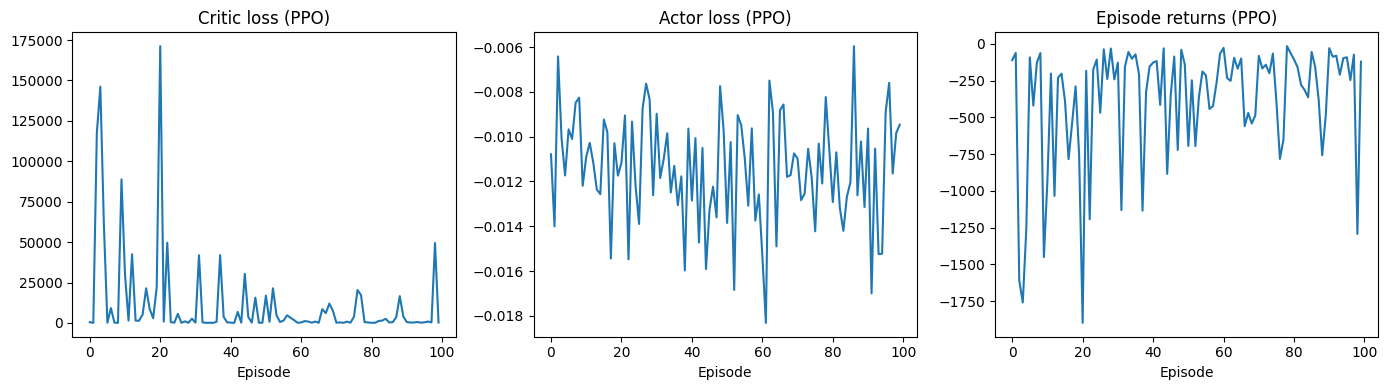

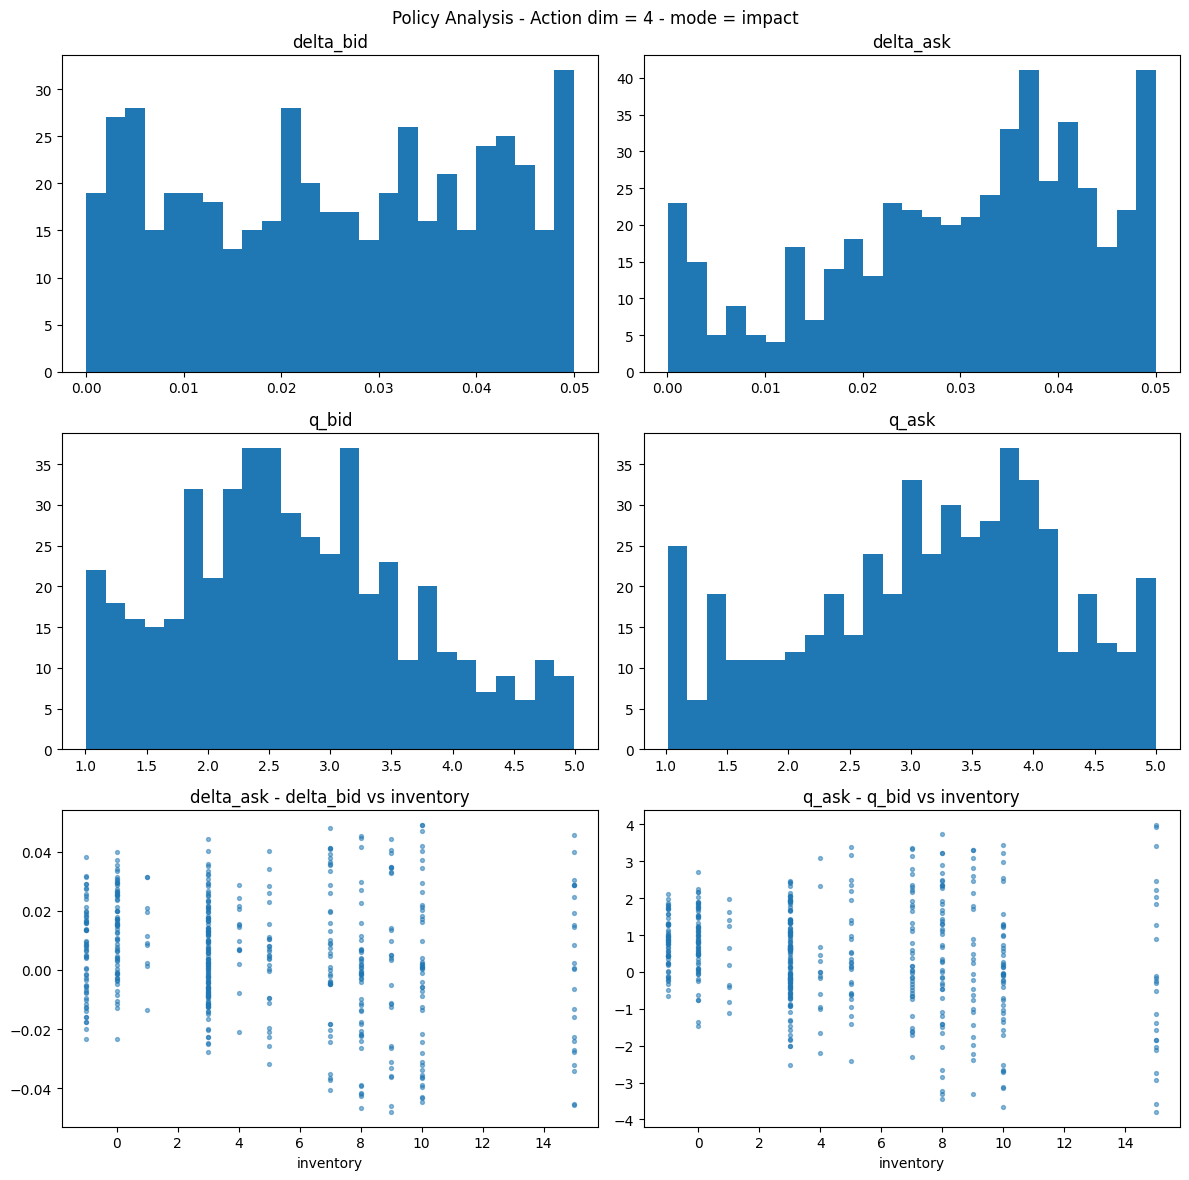

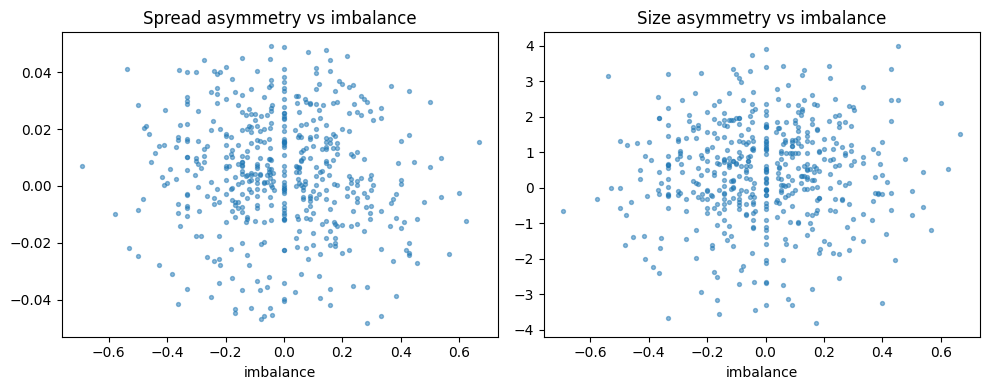

In [25]:
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=100,
    n_epochs_actor=15,
    n_epochs_critic=30,
    random_reset=True,
    max_steps=500,
    verbose=False,
    label="PPO"
)

from src.utils.visualisation import analyze_policy_actions

traj = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=500
)

analyze_policy_actions(traj,env,actor = actor,  inventory_index=-1, imbalance_index=2)

In [26]:
import torch
import time
import matplotlib.pyplot as plt

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

env = MMSimulator(
    csv_path="data/raw/toy_lob.csv",
    seed=42,
    eta_inv=1e-2,
    state_mode="article_like",      
    dynamic_mode="impact"        
)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=4,                
    delta_min=0.0,
    delta_max=0.05,
    q_min=1.0,
    q_max=5.0
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

print("state_dim :", env.state_dim)
print("device    :", device)

state_dim : 7
device    : mps


Temps total : 113.95186281204224

--- Sanity checks (PPO) ---
Nb épisodes : 100
Critic loss (last) : 275.4992980957031
Actor loss  (last) : -0.011948707513511181
Return moyen : -416.1281354904175
Return min / max : -2280.0185546875 -23.266178131103516


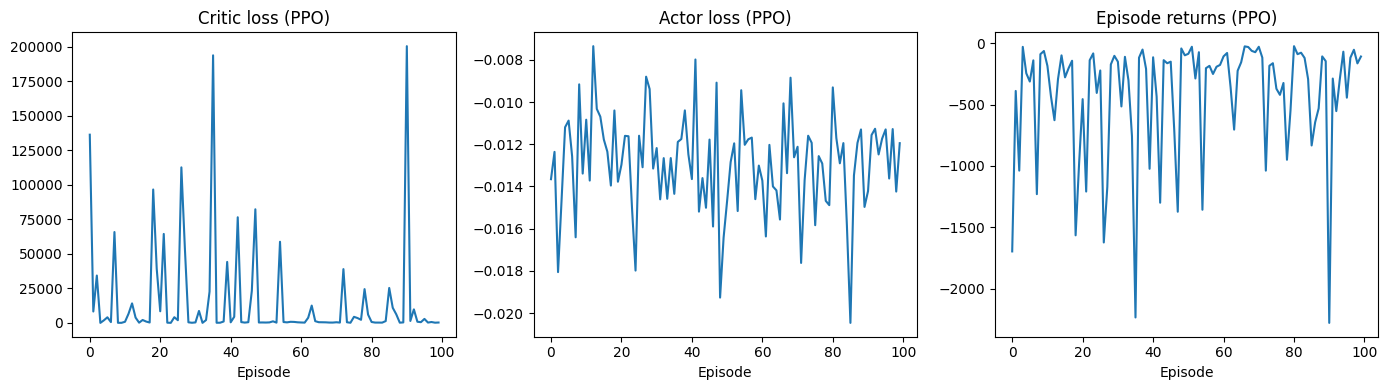

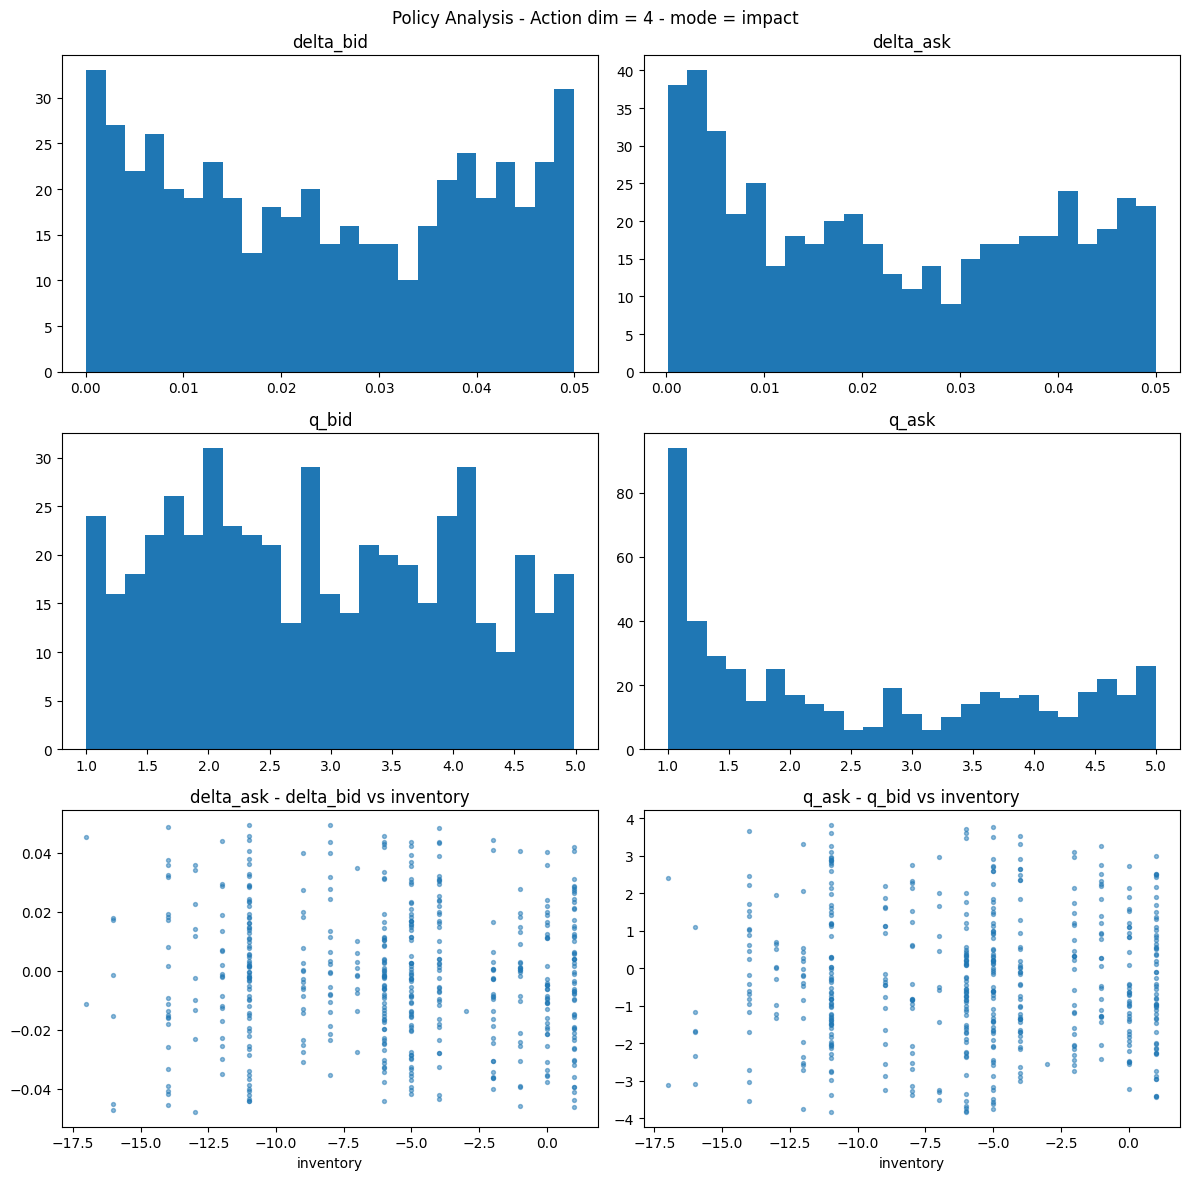

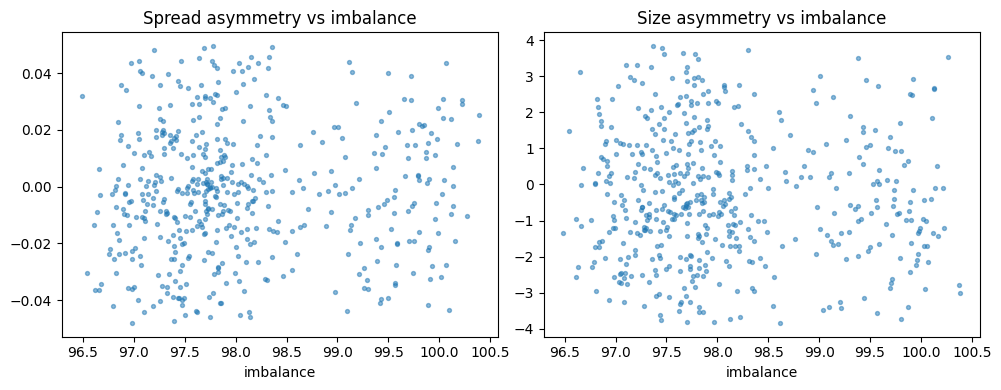

In [27]:
history_ppo, elapsed_ppo = run_training_experiment(
    train_fn=tr_lp.train_ppo,
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=100,
    n_epochs_actor=15,
    n_epochs_critic=30,
    random_reset=True,
    max_steps=500,
    verbose=False,
    label="PPO"
)

from src.utils.visualisation import analyze_policy_actions

traj = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=500
)

analyze_policy_actions(traj,env,actor = actor,  inventory_index=-1, imbalance_index=2)

In [28]:
from src.ppo.losses import Loss

r = traj["rewards"].detach().cpu().numpy()

print("reward mean:", r.mean())

print("reward std :", r.std())

print("reward min :", r.min())

print("reward max :", r.max())

G = Loss.compute_returns(traj["rewards"], gamma=0.99).detach().cpu().numpy()

print("return mean:", G.mean())

print("return std :", G.std())

print("return min :", G.min())

print("return max :", G.max())

reward mean: -0.5410827
reward std : 1.0507406
reward min : -5.583868
reward max : 1.7091091
return mean: -47.42778
return std : 25.054878
return min : -98.10846
return max : 0.5589616


In [29]:
traj = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=500
)

states = traj["states"]
rewards = traj["rewards"]

G = Loss.compute_returns(rewards, gamma=0.99)

with torch.no_grad():
    V = critic(states).reshape(-1)

print("states shape :", states.shape)
print("returns shape:", G.shape)
print("values shape :", V.shape)

print("returns mean/std :", G.mean().item(), G.std().item())
print("values mean/std  :", V.mean().item(), V.std().item())

residual = V - G
print("residual mean/std:", residual.mean().item(), residual.std().item())
print("critic mse :", (residual.pow(2).mean()).item())

states shape : torch.Size([500, 7])
returns shape: torch.Size([500])
values shape : torch.Size([500])
returns mean/std : -16.688608169555664 9.352527618408203
values mean/std  : -33.0733528137207 3.7801398775627604e-06
residual mean/std: -16.384742736816406 9.35252857208252
critic mse : 355.75469970703125


[Device] Using mps
Device : mps
state_mode   : article_like
state_dim    : 7
state_cols   : ['rsi_14', 'imbalance', 'microprice', 'ma_10', 'ma_15', 'ma_30']
reset state  : [  0.          -0.30434783  99.99847826 100.         100.
 100.           0.        ]

Actor : ActorNet(
  (backbone): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
  )
  (mu_head): Linear(in_features=64, out_features=4, bias=True)
  (log_std_head): Linear(in_features=64, out_features=4, bias=True)
)

Critic : CriticNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
 

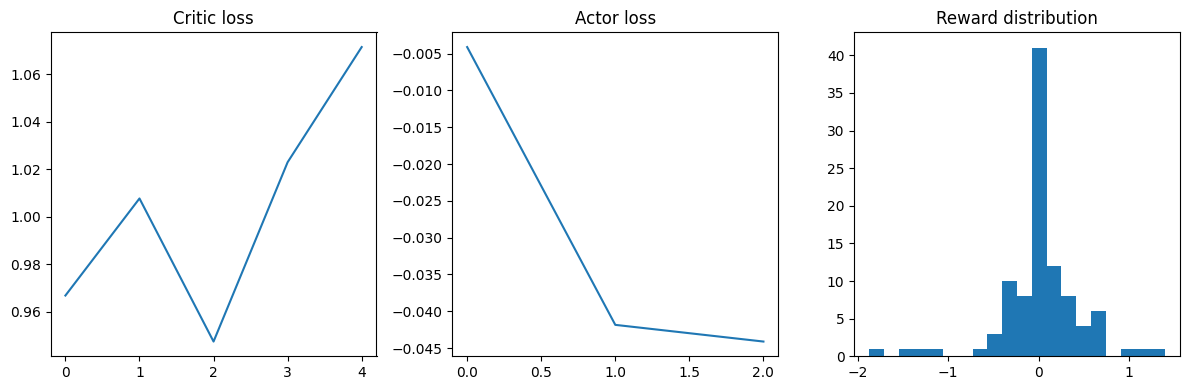


CHECKLIST
✔ no shape errors
✔ losses finite
✔ trajectory collected
✔ GAE computed
✔ PPO one episode runs
If all true -> ready for long training.


In [2]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet, CriticNet
from src.ppo.losses import Loss
import src.ppo.trainers as tr
import scripts.train_loop as tr_lp

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device :", device)

# ------------------------------------------------------------
# Environnement
# ------------------------------------------------------------

env = MMSimulator(
    csv_path="data/raw/toy_lob.csv",
    seed=42,
    state_mode="article_like",     # simple / engineered / article_like
    dynamic_mode="impact"         # baseline / impact
)

print("state_mode   :", env.state_mode)
print("state_dim    :", env.state_dim)
print("state_cols   :", env.state_columns)
print("reset state  :", env.reset())

# ------------------------------------------------------------
# Réseaux
# ------------------------------------------------------------

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=4,          # 1 ou 4
    delta_min=0.0,
    delta_max=0.05,
    q_min=1.0,
    q_max=5.0
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)
print("\nActor :", actor)
print("\nCritic :", critic)

# ------------------------------------------------------------
# Optimizers
# ------------------------------------------------------------

actor_optimizer = torch.optim.Adam(
    actor.parameters(),
    lr=3e-4
)

critic_optimizer = torch.optim.Adam(
    critic.parameters(),
    lr=3e-4
)

# ============================================================
# 1. TEST SAMPLE ACTION
# ============================================================

print("\n==============================")
print("TEST 1 : sample_action")
print("==============================")

s = torch.randn(8, env.state_dim, device=device)

with torch.no_grad():
    a, logp, ent = actor.sample_action(s)

print("states shape :", s.shape)
print("actions shape:", a.shape)
print("log_prob     :", logp.shape)
print("entropy      :", ent.shape)
print("\nFirst actions:")
print(a[:5].cpu())

# ============================================================
# 2. COLLECT TRAJECTORY
# ============================================================

print("\n==============================")
print("TEST 2 : collect_trajectory")
print("==============================")

traj = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=100
)

for k, v in traj.items():
    print(k, v.shape)

# ============================================================
# 3. VALUES / GAE / RETURNS
# ============================================================

print("\n==============================")
print("TEST 3 : values / gae / returns")
print("==============================")

with torch.no_grad():
    values = critic(traj["states"]).reshape(-1)
    next_values = critic(traj["next_states"]).reshape(-1)

advantages = Loss.compute_gae(
    rewards=traj["rewards"],
    values=values,
    next_values=next_values,
    dones=traj["dones"],
    gamma=0.99,
    lam=0.85
)

returns = Loss.compute_ppo_returns(
    advantages=advantages,
    values=values
)

print("values shape      :", values.shape)
print("advantages shape  :", advantages.shape)
print("returns shape     :", returns.shape)
print("\nvalues mean/std      :", values.mean().item(), values.std().item())
print("advantages mean/std  :", advantages.mean().item(), advantages.std().item())
print("returns mean/std     :", returns.mean().item(), returns.std().item())

# ============================================================
# 4. TEST LOSSES
# ============================================================
print("\n==============================")
print("TEST 4 : actor / critic losses")
print("==============================")

with torch.no_grad():
    log_prob, entropy = actor.evaluate_actions(
        traj["states"],
        traj["actions"]
    )

actor_loss = Loss.actor_loss_ppo_fn(
    log_prob=log_prob,
    old_log_prob=traj["old_log_probs"],
    A=advantages,
    entropy=entropy,
    eps_clip=0.25,
    entropy_coef=1.2e-3
)

critic_loss = Loss.critic_loss_fn(
    critic,
    traj["states"],
    returns
)

print("actor_loss  :", actor_loss.item())
print("critic_loss :", critic_loss.item())
# ============================================================
# 5. ONE TRAINING STEP
# ============================================================

print("\n==============================")
print("TEST 5 : one PPO episode")
print("==============================")

t0 = time.time()

l_hist_critic, l_hist_actor, ep_return = tr_lp.train_one_episode_ppo(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    lam=0.85,
    n_epochs_actor=3,
    n_epochs_critic=5,
    batch_size=64,
    random_reset=True,
    max_steps=100,
    verbose=True
)

elapsed = time.time() - t0

print("\ncritic loss last :", l_hist_critic[-1])
print("actor loss last  :", l_hist_actor[-1])
print("episode return   :", ep_return)
print("elapsed time     :", elapsed)

# ============================================================
# 6. QUICK PLOTS
# ============================================================

print("\n==============================")
print("TEST 6 : plots")
print("==============================")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(l_hist_critic)
plt.title("Critic loss")
plt.subplot(1,3,2)
plt.plot(l_hist_actor)
plt.title("Actor loss")
plt.subplot(1,3,3)
plt.hist(
    traj["rewards"].cpu().numpy(),
    bins=20
)
plt.title("Reward distribution")
plt.tight_layout()
plt.show()
# ============================================================
# CHECKLIST
# ============================================================

print("\n==============================")
print("CHECKLIST")
print("==============================")
print("✔ no shape errors")
print("✔ losses finite")
print("✔ trajectory collected")
print("✔ GAE computed")
print("✔ PPO one episode runs")
print("If all true -> ready for long training.")